<!-- EDA Header / UX-style -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: linear-gradient(90deg, #EE7F2D 0%, #FFB56B 100%);
  color: #ffffff;
  padding: 18px 22px;
  border-radius: 14px;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
  margin: 10px 0 14px 0;
">
  <div style="
    display:inline-block;
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    background: rgba(255,255,255,0.16);
    padding: 6px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
  ">
    Give Me Some Credit • Exploratory Data Analysis 2
  </div>

  <div style="
    font-size: 30px;
    font-weight: 800;
    line-height: 1.15;
    margin: 6px 0 6px 0;
  ">
    Correlation & Feature Evaluation
  </div>

  <div style="
    font-size: 15px;
    line-height: 1.5;
    opacity: .95;
    max-width: 980px;
  ">
    We explored the <b>cs-train_processed.csv</b> dataset to evaluate feature behavior,
    predictive strength, redundancy, and overall contribution to default risk.
  </div>
</div>

<!-- Optional section  -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 14px 16px;
  border-radius: 12px;
  margin: 0 0 10px 0;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
">
  <div style="
    font-weight: 800;
    margin-bottom: 8px;
    letter-spacing: .02em;
  ">
    What we covered
  </div>

  <ul style="
    margin: 0 0 0 18px;
    line-height: 1.65;
  ">
    <li>Loaded and analyzed the preprocessed dataset</li>
    <li>Performed bivariate analysis (KDE, Violin plots, Decile analysis)</li>
    <li>Evaluated linear and monotonic relationships (Pearson & Spearman)</li>
    <li>Measured predictive strength using AUC</li>
    <li>Measured categorical association using Cramér’s V</li>
    <li>Engineered new features (e.g., dpd_severity)</li>
    <li>Removed redundant and low-signal variables</li>
    The results obtained in this notebook will updata preprocess script.
  </ul>
</div>

<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: linear-gradient(90deg, #5B4661 0%, #918395 100%);
  color: #ffffff;
  padding: 16px 20px;
  border-radius: 14px;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
  margin: 14px 0 12px 0;
">
  <div style="
    display:inline-block;
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    background: rgba(255,255,255,0.16);
    padding: 6px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
  ">
    IMPORTING
  </div>

  <div style="
    font-size: 22px;
    font-weight: 800;
    line-height: 1.2;
    margin: 0 0 6px 0;
  ">
    Importing Libraries and Dataframes
  </div>

  <div style="
    font-size: 13px;
    line-height: 1.5;
    opacity: .92;
    max-width: 980px;
  ">
    R Libraries, training and disctionary dataframes
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Importing Dataframes ~csv
  </div>
</div>

In [643]:
path_df <- "cs_train_processed.csv"
df <- read.csv(path_df)

#preview
head(df, 10)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,util_gt1,util_gt10,dr_unreliable,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,income_extreme_flag,real_estate_bucket
1,1,0.5687888,45,2,8.029821e-01,9120,13,0,6,...,FALSE,FALSE,FALSE,0,0.58944203,FALSE,9120,9.118335,FALSE,4
2,0,0.6714899,40,0,1.218762e-01,2600,4,0,0,...,FALSE,FALSE,FALSE,0,0.11500246,FALSE,2600,7.863651,FALSE,0
3,0,0.5057207,38,1,8.511338e-02,3042,2,1,0,...,FALSE,FALSE,FALSE,0,0.08168447,FALSE,3042,8.020599,FALSE,0
4,0,0.2101068,30,0,3.604968e-02,3300,5,0,0,...,FALSE,FALSE,FALSE,0,0.03541510,FALSE,3300,8.101981,FALSE,0
5,0,0.6456569,49,1,2.492570e-02,63588,7,0,1,...,FALSE,FALSE,FALSE,0,0.02462012,FALSE,31250,10.349807,TRUE,1
6,0,0.1932439,74,0,3.756070e-01,3500,3,0,1,...,FALSE,FALSE,FALSE,0,0.31889507,FALSE,3500,8.160804,FALSE,1
7,0,0.2667259,57,0,5.710000e+03,5400,8,0,3,...,FALSE,FALSE,TRUE,2,4.61512052,FALSE,5400,8.594339,FALSE,3
8,0,0.5621632,39,0,2.099400e-01,3500,8,0,0,...,FALSE,FALSE,FALSE,0,0.19057079,FALSE,3500,8.160804,FALSE,0
9,0,0.1106023,27,0,4.600000e+01,5400,2,0,0,...,FALSE,FALSE,FALSE,0,3.85014760,FALSE,5400,8.594339,FALSE,0
10,0,0.1732548,57,0,6.062909e-01,23684,9,0,4,...,FALSE,FALSE,FALSE,0,0.47392773,FALSE,23684,10.072597,FALSE,3


In [644]:
train_df <- "cs_train_processed.csv"
df <- read.csv(train_df)

#preview
head(df, 10)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,util_gt1,util_gt10,dr_unreliable,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,income_extreme_flag,real_estate_bucket
1,1,0.5687888,45,2,8.029821e-01,9120,13,0,6,...,FALSE,FALSE,FALSE,0,0.58944203,FALSE,9120,9.118335,FALSE,4
2,0,0.6714899,40,0,1.218762e-01,2600,4,0,0,...,FALSE,FALSE,FALSE,0,0.11500246,FALSE,2600,7.863651,FALSE,0
3,0,0.5057207,38,1,8.511338e-02,3042,2,1,0,...,FALSE,FALSE,FALSE,0,0.08168447,FALSE,3042,8.020599,FALSE,0
4,0,0.2101068,30,0,3.604968e-02,3300,5,0,0,...,FALSE,FALSE,FALSE,0,0.03541510,FALSE,3300,8.101981,FALSE,0
5,0,0.6456569,49,1,2.492570e-02,63588,7,0,1,...,FALSE,FALSE,FALSE,0,0.02462012,FALSE,31250,10.349807,TRUE,1
6,0,0.1932439,74,0,3.756070e-01,3500,3,0,1,...,FALSE,FALSE,FALSE,0,0.31889507,FALSE,3500,8.160804,FALSE,1
7,0,0.2667259,57,0,5.710000e+03,5400,8,0,3,...,FALSE,FALSE,TRUE,2,4.61512052,FALSE,5400,8.594339,FALSE,3
8,0,0.5621632,39,0,2.099400e-01,3500,8,0,0,...,FALSE,FALSE,FALSE,0,0.19057079,FALSE,3500,8.160804,FALSE,0
9,0,0.1106023,27,0,4.600000e+01,5400,2,0,0,...,FALSE,FALSE,FALSE,0,3.85014760,FALSE,5400,8.594339,FALSE,0
10,0,0.1732548,57,0,6.062909e-01,23684,9,0,4,...,FALSE,FALSE,FALSE,0,0.47392773,FALSE,23684,10.072597,FALSE,3


In [645]:
#path_raw <- "../database/cs-training.csv"

<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: linear-gradient(90deg, #5B4661 0%, #918395 100%);
  color: #ffffff;
  padding: 16px 20px;
  border-radius: 14px;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
  margin: 14px 0 12px 0;
">
  <div style="
    display:inline-block;
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    background: rgba(255,255,255,0.16);
    padding: 6px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
  ">
    EDA
  </div>

  <div style="
    font-size: 22px;
    font-weight: 800;
    line-height: 1.2;
    margin: 0 0 6px 0;
  ">
    Bivariate Analysis
  </div>

  <div style="
    font-size: 13px;
    line-height: 1.5;
    opacity: .92;
    max-width: 980px;
  ">
    Default rate by deciles (bins by quantiles) + KDE + Violin Plot
  </div>
</div>

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - Bivariate Analysis
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    Why perform bivariate analysis:

    - Visualization of which features have a true signal versus the target

    - Whether the effect is monotonic (good for LR/scorecard)

    - Whether buckets/flags/interactions are needed.

    - Whether there is a category/range with high lift and high support (important)
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Definition of the functions to be applied
  </div>
</div>

In [646]:
bivar_num_bins <- function(width = 13, height = 5) {
  options(
    repr.plot.width  = width,
    repr.plot.height = height,
    repr.plot.bg     = "white"
  )
  par(
    bg = "white",
    col.axis = "black",
    col.lab  = "black",
    col.main = "black"
  )
  invisible(TRUE)
}

bivar_num_bins <- function(df, col, target="default_2y", bins=10){
  x <- df[[col]]
  y <- df[[target]]
  base_rate <- mean(y, na.rm = TRUE)

  brks <- unique(quantile(x, probs = seq(0, 1, length.out = bins + 1), na.rm = TRUE))
  if (length(brks) < 3) stop("Little variation in the variable for binning.")

  b <- cut(x, breaks = brks, include.lowest = TRUE)
  tab <- aggregate(y ~ b, FUN = function(v) c(n = length(v), rate = mean(v, na.rm = TRUE)))

  tab <- data.frame(
    bin = tab$b,
    n = tab$y[, "n"],
    default_rate = tab$y[, "rate"]
  )
  tab$lift <- tab$default_rate / base_rate
  tab
}

plot_default_rate_bins <- function(tab, title="Default rate per bins",
                                   color_main = "#5B4661",
                                   color_ref  = "#999999") {
  op <- par(mar = c(8, 4, 3.5, 1), bg = "white",
            col.axis = "black", col.lab = "black", col.main = "black")
  on.exit(par(op), add = TRUE)

  plot(tab$default_rate,
       type = "b",
       pch = 19,
       col = color_main,
       lwd = 2,
       xaxt = "n",
       xlab = "",
       ylab = "Default rate",
       main = title)

  axis(1, at = 1:nrow(tab), labels = as.character(tab$bin), las = 2, cex.axis = 0.8)


  abline(h = mean(tab$default_rate, na.rm = TRUE), lty = 2, lwd = 2, col = color_ref)
}


In [647]:
plot_violin_by_target <- function(df, col, target="default_2y",
                                  purple="#5B4661", grey="#B0B0B0") {
  x0 <- df[[col]][df[[target]]==0]
  x1 <- df[[col]][df[[target]]==1]

  op <- par(bg="white", col.axis="black", col.lab="black", col.main="black")
  on.exit(par(op), add=TRUE)

  plot(NA, xlim=c(0.5,2.5), ylim=range(c(x0,x1), na.rm=TRUE),
       xaxt="n", xlab="", ylab=col, main=paste("Violin/Box:", col))
  axis(1, at=c(1,2), labels=c("target=0","target=1"))

  add_violin <- function(x, at, col_fill){
    d <- density(x, na.rm=TRUE)
    d$y <- d$y / max(d$y) * 0.35
    polygon(c(at - d$y, rev(at + d$y)), c(d$x, rev(d$x)),
            col=adjustcolor(col_fill, alpha.f=0.20), border=NA)
    lines(rep(at, length(d$x)), d$x, col=adjustcolor(col_fill, alpha.f=0))
    boxplot(x, at=at, add=TRUE, width=0.12, outline=FALSE,
            border=col_fill, col=adjustcolor(col_fill, alpha.f=0.25))
  }

  add_violin(x0, 1, grey)
  add_violin(x1, 2, purple)
}

In [648]:
plot_kde_simple <- function(df, col, target="default_2y",
                            purple="#5B4661", grey="#B0B0B0") {
  x0 <- df[[col]][df[[target]]==0 & !is.na(df[[col]])]
  x1 <- df[[col]][df[[target]]==1 & !is.na(df[[col]])]

  d0 <- density(x0)
  d1 <- density(x1)

  op <- par(bg="white", col.axis="black", col.lab="black", col.main="black")
  on.exit(par(op), add=TRUE)

  plot(d0, col=grey, lwd=2, lty=2,
       main=paste("KDE by target:", col), xlab=col, ylab="Densidade")
  lines(d1, col=purple, lwd=2.5)
  legend("topright", legend=c("target=0","target=1"),
         col=c(grey,purple), lty=c(2,1), lwd=c(2,2.5), bty="n")
}

In [649]:
plot_bivar_bundle_base <- function(df, col, target="default_2y", bins=10){
  op <- par(mfrow=c(1,3), bg="white")
  on.exit(par(op), add=TRUE)

  tab <- bivar_num_bins(df, col, target=target, bins=bins)
  plot_default_rate_bins(tab, paste(col, ": default rate by decis"))

  plot_kde_simple(df, col, target=target)
  plot_violin_by_target(df, col, target=target)

}

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    util_unsecured
  </div>
</div>

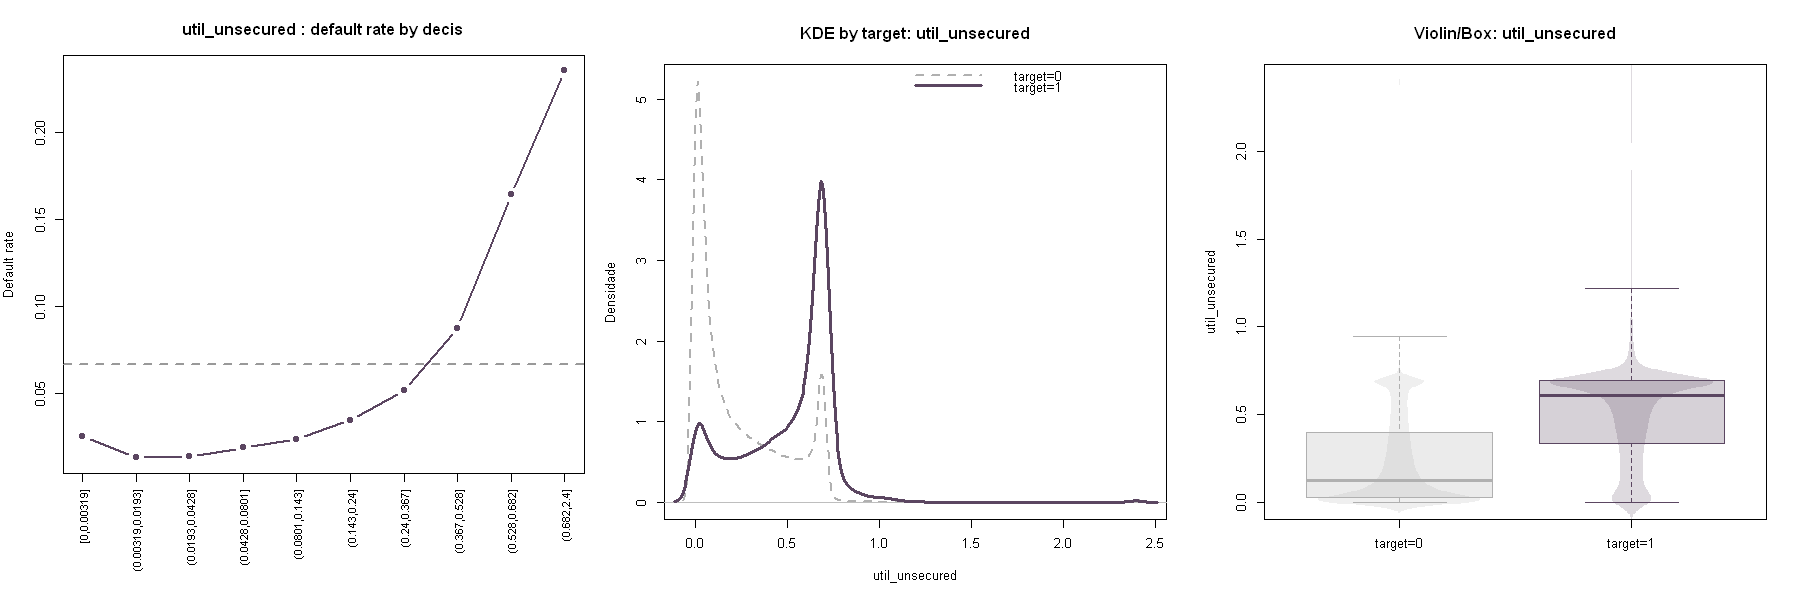

In [650]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "util_unsecured", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - util_unsecured results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    What does this result mean?

    The proportion is almost perfectly monotonic — the rate rises consistently from decile 1 to 10, without inversions.

    Decile 1 (utilization between 0 and 0.003): rate of 2.6% — lift of 0.38, meaning this group is 62% less delinquent than the average.

    Decile 10 (utilization between 0.68 and 2.4): rate of 23.5% — lift of 3.5, meaning this group is 3.5 times more delinquent than the average.

    util_unsecured is a strong, monotonic predictor with a well-calibrated effect.

    The violin plot numerically confirms what KDE shows visually. Median of paying customers ~0.15, median of non-paying customers ~0.6. The IQR for target=1 is entirely above the IQR for target=0 — a clear and consistent separation.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    age_years
  </div>
</div>

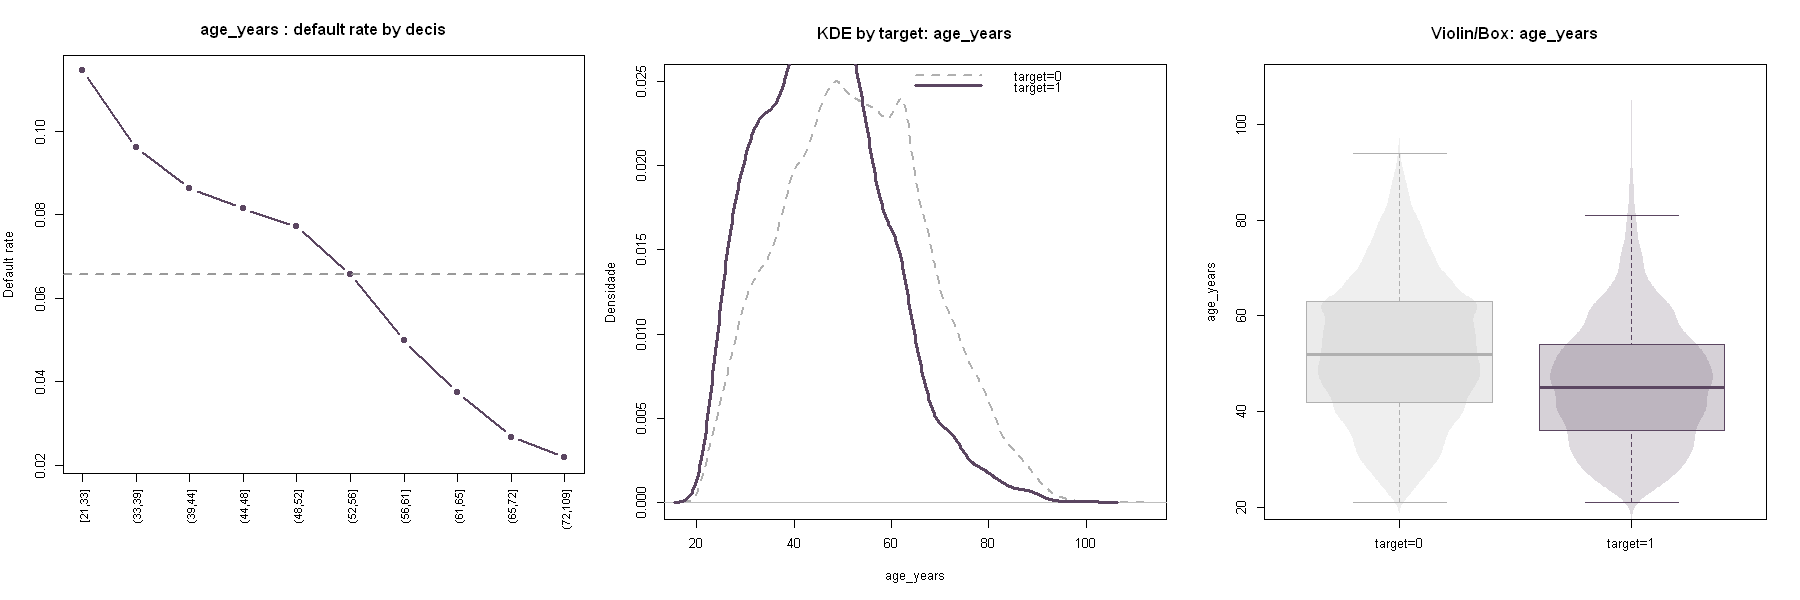

In [651]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "age_years", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - age_years results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decile Curve: Monotonic negative and consistent relationship — the older the age, the lower the risk. The first decile (21–33 years) has a rate of ~12%, the last (72–109) drops to ~2%. C.

    - KDE: Delinquents (solid) concentrated between 20–50 years, peaking at ~40. Payers (dashed lines) shifted to the right, peaking at ~55.

    - Violin/Box: Median of defaulters ~45 years vs ~52 of payers. IQRs overlap considerably — the difference between the groups is real, but moderate.

    Conclusion: Monotonic and clean effect. However, distributions mix considerably in the center. Lower weight for models.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dpd_30_59_cnt
  </div>
</div>

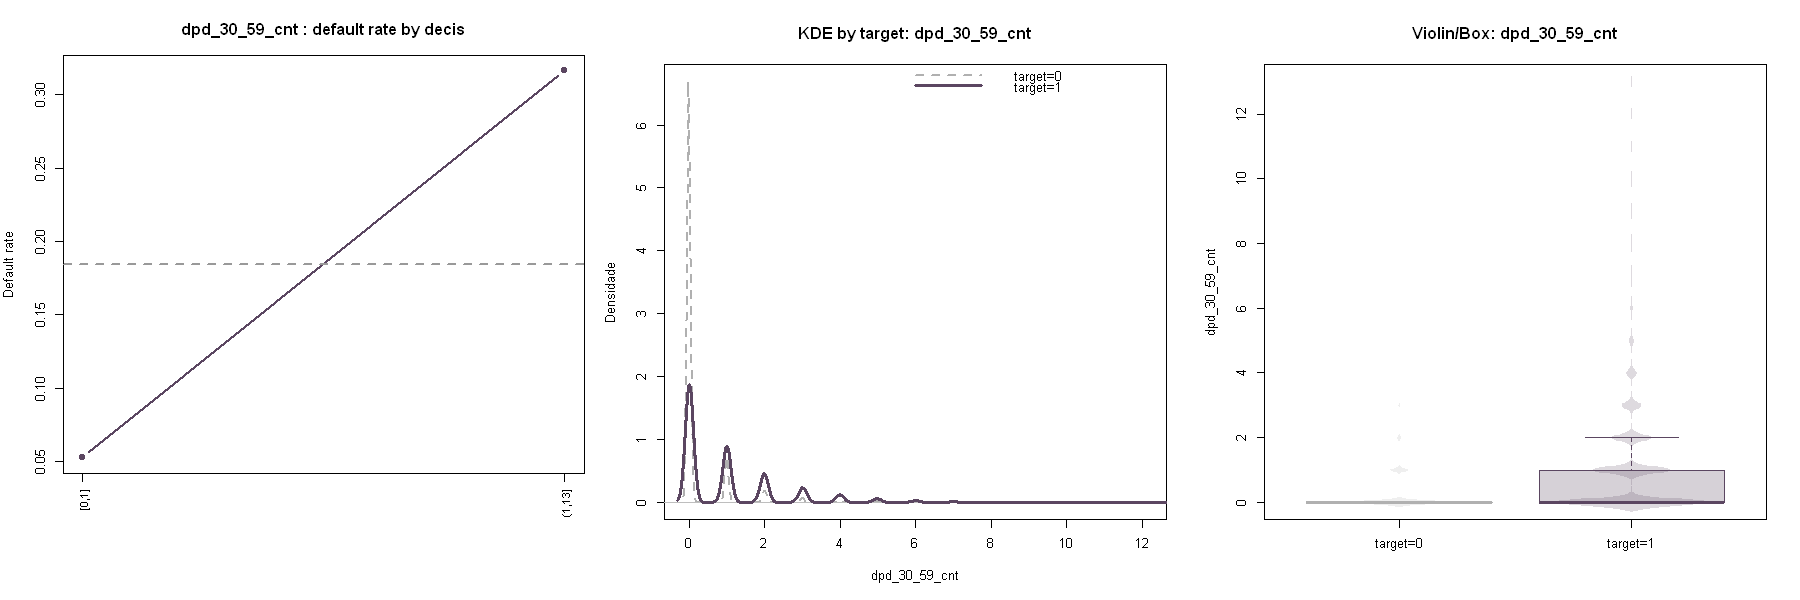

In [652]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "dpd_30_59_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dpd_30_59_cnt results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decile curve: Only two bins — the variable is almost entirely zero. Those who have never been late (bin 0) have a rate of ~5%, those who have been late at least once (bin 1+) jump to ~32%.

    - KDE: Both classes concentrated at 0, but those who are on time (dashed line) have a much higher and narrower peak — almost no one is late.

    - Violin/Box: Those who are on time: median 0, IQR practically zero — almost homogeneous population. Those who are not on time: median ~1, IQR from 0 to 2, with outliers above 4.

    Conclusion: Strong signal concentrated in the zero vs. non-zero distinction. The marginal effect of 2 vs. 3 late payments exists but is smaller. Create a binary flag dpd_30_59_ever (0 vs. 1+) that better captures where the signal is.
    
  </div>
</div>

In [653]:
df$dpd_30_59_ever <- as.integer(df$dpd_30_59_cnt > 0)
df$dpd_60_89_ever <- as.integer(df$dpd_60_89_cnt > 0)
df$dpd_90p_ever   <- as.integer(df$dpd_90p_cnt   > 0)

head(df, 10)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,income_extreme_flag,real_estate_bucket,dpd_30_59_ever,dpd_60_89_ever,dpd_90p_ever
1,1,0.5687888,45,2,8.029821e-01,9120,13,0,6,...,0,0.58944203,FALSE,9120,9.118335,FALSE,4,1,0,0
2,0,0.6714899,40,0,1.218762e-01,2600,4,0,0,...,0,0.11500246,FALSE,2600,7.863651,FALSE,0,0,0,0
3,0,0.5057207,38,1,8.511338e-02,3042,2,1,0,...,0,0.08168447,FALSE,3042,8.020599,FALSE,0,1,0,1
4,0,0.2101068,30,0,3.604968e-02,3300,5,0,0,...,0,0.03541510,FALSE,3300,8.101981,FALSE,0,0,0,0
5,0,0.6456569,49,1,2.492570e-02,63588,7,0,1,...,0,0.02462012,FALSE,31250,10.349807,TRUE,1,1,0,0
6,0,0.1932439,74,0,3.756070e-01,3500,3,0,1,...,0,0.31889507,FALSE,3500,8.160804,FALSE,1,0,0,0
7,0,0.2667259,57,0,5.710000e+03,5400,8,0,3,...,2,4.61512052,FALSE,5400,8.594339,FALSE,3,0,0,0
8,0,0.5621632,39,0,2.099400e-01,3500,8,0,0,...,0,0.19057079,FALSE,3500,8.160804,FALSE,0,0,0,0
9,0,0.1106023,27,0,4.600000e+01,5400,2,0,0,...,0,3.85014760,FALSE,5400,8.594339,FALSE,0,0,0,0
10,0,0.1732548,57,0,6.062909e-01,23684,9,0,4,...,0,0.47392773,FALSE,23684,10.072597,FALSE,3,0,0,0


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    debt_ratio
  </div>
</div>

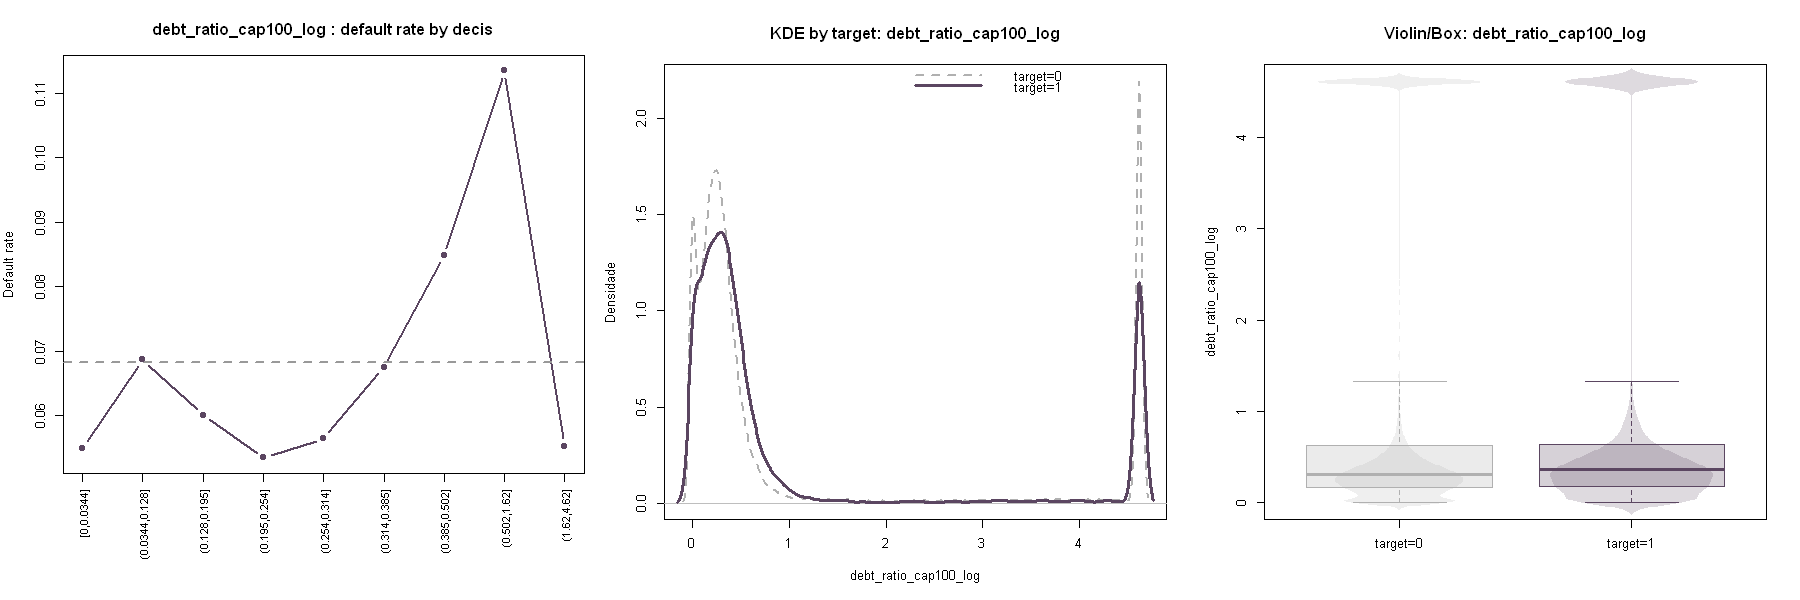

In [654]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "debt_ratio_cap100_log", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - debt_ratio_cap100_log results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decision Curve: The relationship is not monotonic: in low/medium bins, the default rate is near/below the average (~6.7%), then rises sharply in high bins and falls.

    - KDE: Both classes have a large mass at low debt_ratio_cap100_log values ​​(near 0–0.6), with a slight shift between the curves. The highlight is the very narrow peak at the far right (~4.6).

    - Violin/Box: The distributions are very similar in the middle: close medians and similar IQRs, with the target=1 class slightly above.

    - Conclusion: debt_ratio_cap100_log has a moderate signal and is not perfectly monotonic, with risk increasing in the high ranges, but with loss of information at the top due to the cap.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    monthly_income
  </div>
</div>

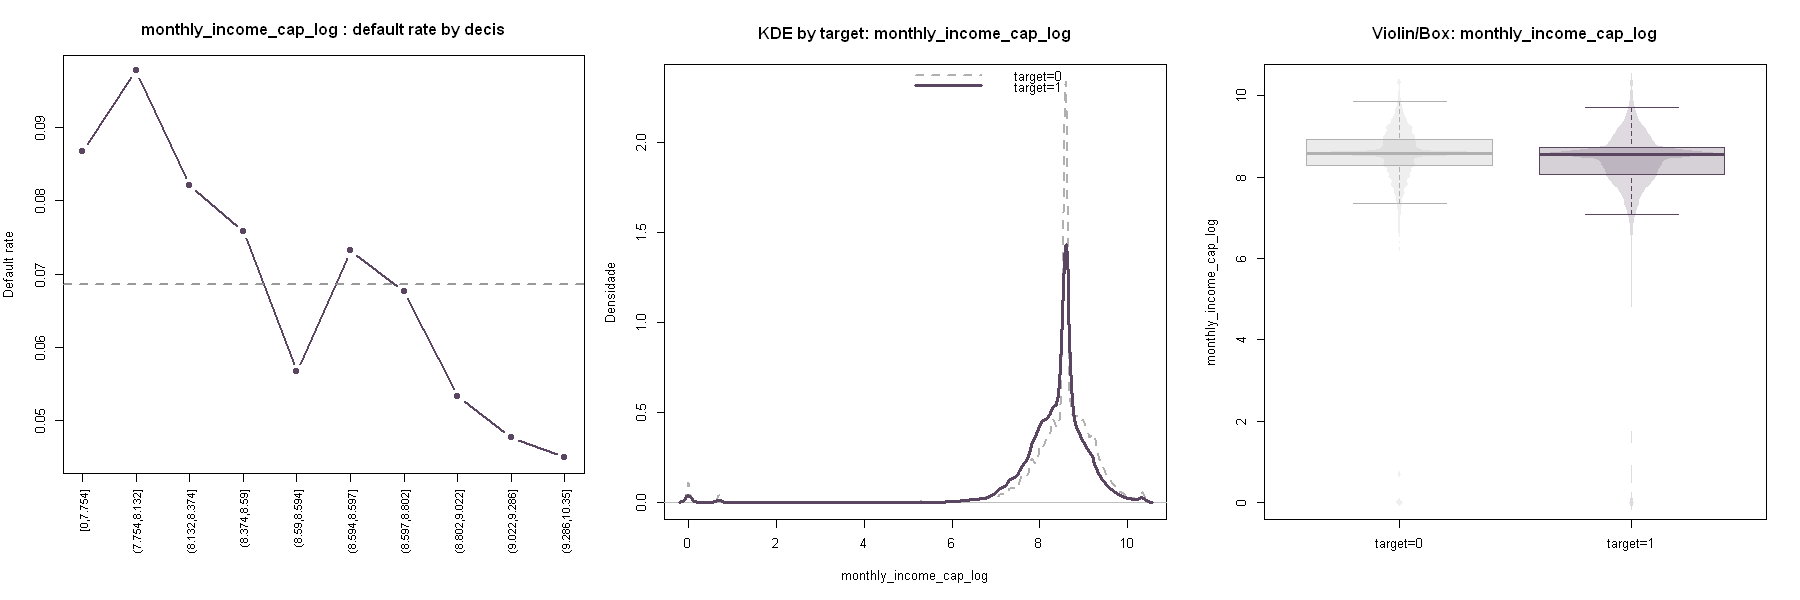

In [655]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "monthly_income_cap_log", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - monthly_income results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decision Curve: The relationship is a clear monotonic decreasing pattern: in the bins with the lowest monthly_income_cap_log, the default rate is above average (~8–10%), and it consistently falls until the highest bins, reaching close to ~4–5%.

    - KDE: The two classes are concentrated in the middle (peak around ~8–9 on the log axis), but the curve of defaulters (dashed) appears slightly shifted to the left.

    - Violin/Box: Target=1 has a lower median and a slightly more "spread" distribution downwards (heavier lower tail), while target=0 is more concentrated in higher values.

    Conclusion: monthly_income_cap_log is a variable with a stable and monotonic (negative) sign, delivering a "clean" relationship with the target.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    open_credit_cnt
  </div>
</div>

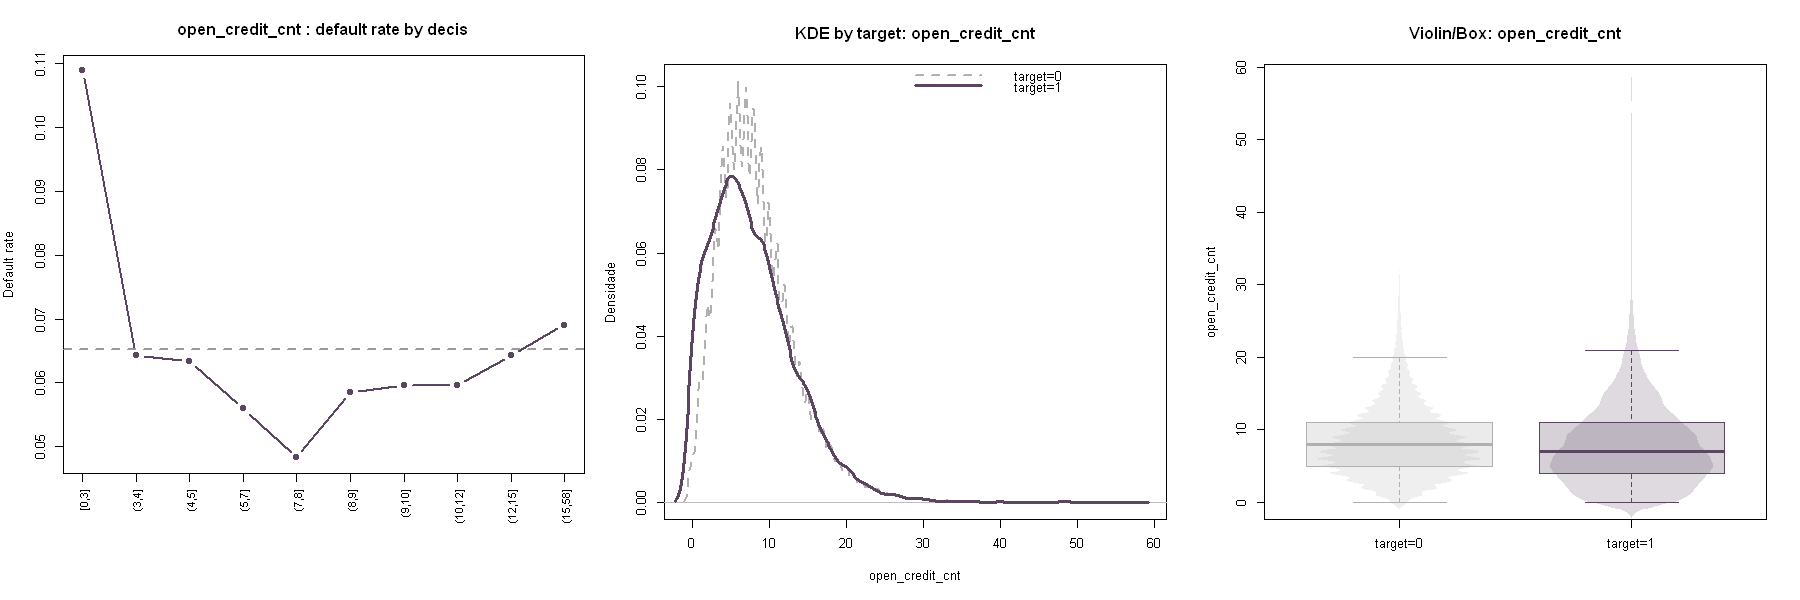

In [656]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "open_credit_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - open_credit_cnt results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decision Curve: Higher risk at the extremes (very few or many lines), with a "lower risk zone" in the middle.

    - KDE: The two distributions are very similar and concentrated in the middle (~3 to 12), with a long tail on the right. The overlap is large — the signal exists, but it is weak to moderate.

    - Violin/Box: The medians are close, with the target=1 slightly lower and a similar dispersion.

    - Conclusion: open_credit_cnt has a moderate and non-monotonic signal: alone it is not a strong "driver," but it can help the model by capturing an extreme effect.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dpd_90p_cnt
  </div>
</div>

In [657]:
#options(repr.plot.width = 15, repr.plot.height = 5)
#plot_bivar_bundle_base(df, "dpd_90p_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dpd_90p_cnt
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    It is not possible to generate the graphs due to the low variation in deciles. However, cases greater than 1 have already been flagged from the previous dpd subsection.
    
  </div>
</div>

In [658]:
# Alternative bivariate analysis

bivar_bucket_0_1_2p <- function(df, col, target="default_2y"){
  x <- df[[col]]
  y <- df[[target]]
  base_rate <- mean(y, na.rm=TRUE)

  b <- ifelse(is.na(x), NA,
              ifelse(x==0, "0",
                     ifelse(x==1, "1", "2+")))
  b <- factor(b, levels=c("0","1","2+"), exclude=NULL)

  tab <- aggregate(y ~ b, FUN=function(v) c(n=length(v), rate=mean(v, na.rm=TRUE)))
  tab <- data.frame(
    bucket = tab$b,
    n = tab$y[, "n"],
    default_rate = tab$y[, "rate"]
  )
  tab$lift <- tab$default_rate / base_rate
  tab
}

tab <- bivar_bucket_0_1_2p(df, "dpd_90p_cnt")
tab

bucket,n,default_rate,lift
0,141107,0.04641159,0.6927193
1,5232,0.33715596,5.0322439
2+,2826,0.55201699,8.2391665


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dpd_90p_cnt Results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    Bins Curve (0 / 1 / 2+) The variable has a very strong and monotonic signal.

    0 delays: n=141,107, default ~4.64%, lift ~0.69x (below the dataset's average rate).

    1 delay: n=5,232, default ~33.72%, lift ~5.03x (huge jump vs. zero).

    2+ delays: n=2,826, default ~55.20%, lift ~8.24x (very high risk, even higher).

    Note: the dataset is unbalanced, so what matters here is the rate, not the count — even with smaller groups (1 and 2+), the risk explodes.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    real_estate_cnt
  </div>
</div>

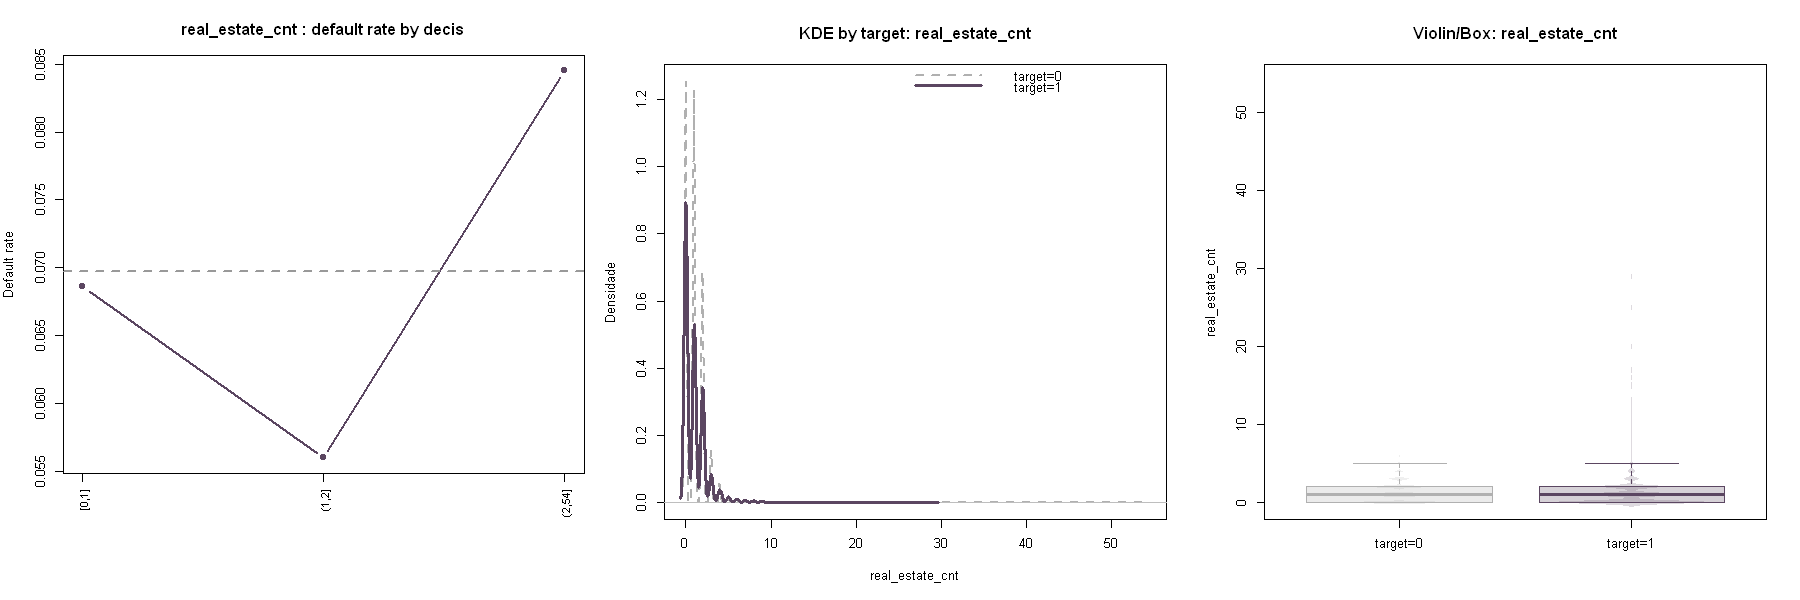

In [659]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "real_estate_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - real_estate_cnt results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decile Curve: The curve has few effective bins (discrete variable concentrated at low values). The pattern suggests non-monotonic/irregular behavior.

    - KDE: The curves are well overlapped; if there is a difference, it is subtle.

    - Violin/Box: Medians are very close and IQRs are small. The target=1 class does not clearly separate from the target=0 class.

    Conclusion: real_estate_cnt has a weak signal, with some evidence of higher risk at 2+ (extreme) and lower risk in the middle.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dpd_60_89_cnt
  </div>
</div>

In [660]:
#options(repr.plot.width = 15, repr.plot.height = 5)
#plot_bivar_bundle_base(df, "dpd_60_89_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dpd_60_89_cnt
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    It is not possible to generate the graphs due to the low variation in deciles. However, cases greater than 1 have already been flagged from the previous dpd subsection.
    
  </div>
</div>

In [661]:
# Alternative bivariate analysis

tab <- bivar_bucket_0_1_2p(df, "dpd_60_89_cnt")
tab

bucket,n,default_rate,lift
0,141830,0.05111754,0.7629582
1,5731,0.31006805,4.6279415
2+,1604,0.52743142,7.8722130


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dpd_60_89_cnt results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Bins curve (0 / 1 / 2+) The variable shows a strong and monotonic signal. 
    0 delays: n=141,830, default ~5.11%, lift ~0.76x (below the dataset mean).
    1 delay: n=5,731, default ~31.01%, lift ~4.63x (large jump vs. zero).
    2+ delays: n=1,604, default ~52.74%, lift ~7.87x (extremely high risk).
    The reading is quite straightforward: the “step” 0 → 1 → 2+ captures practically the entire signal.
    
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dependents_cnt
  </div>
</div>

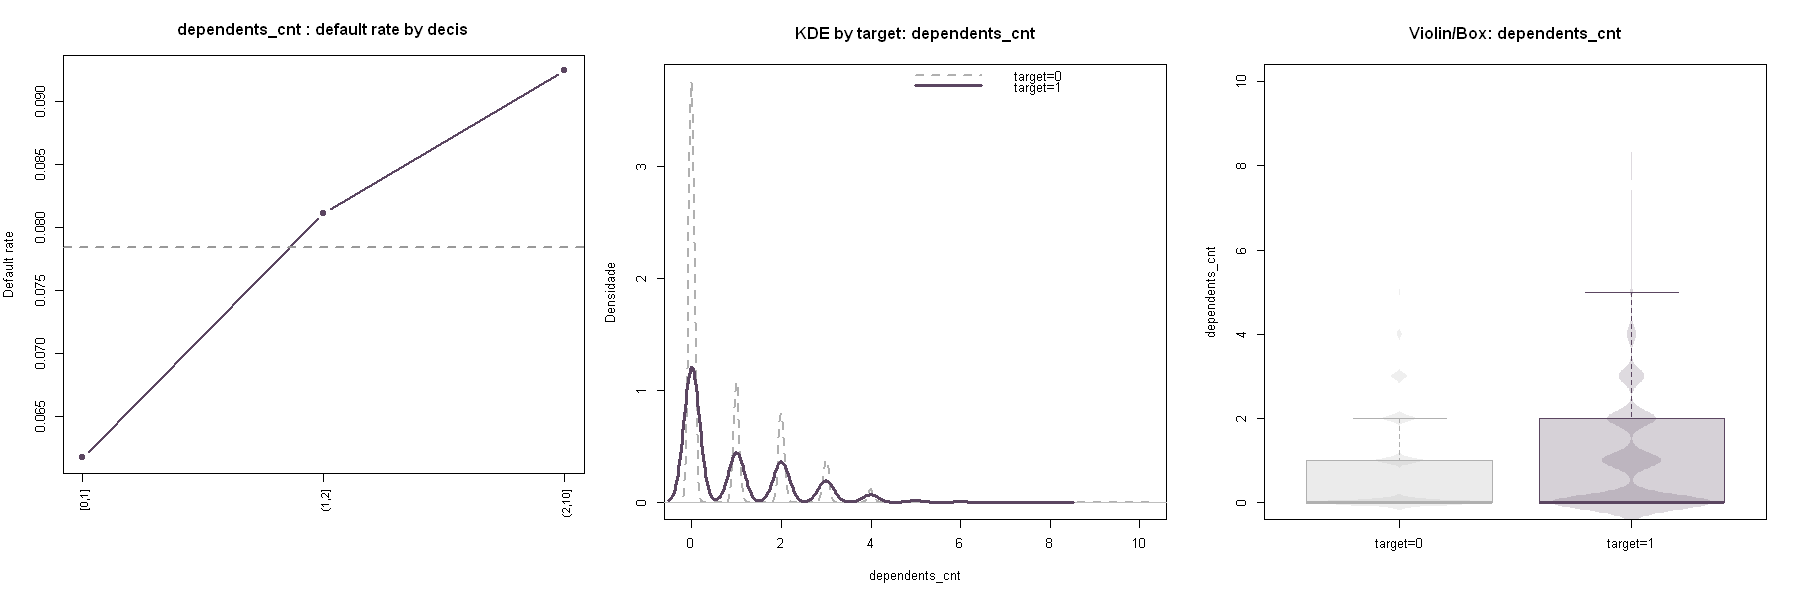

In [662]:
options(repr.plot.width = 15, repr.plot.height = 5)
plot_bivar_bundle_base(df, "dependents_cnt", target="default_2y", bins=10)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    NOTE - dependents_cnt results
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    - Decile Curve: The relationship is monotonically increasing (in steps, because the variable is discrete). It can be seen that more dependents → greater risk, with a visible effect starting from ~2 dependents.

    - KDE: The distributions are discrete (peaks at 0, 1, 2, 3…), and the two classes have a lot of mass at 0. But without perfect separation (a lot of overlap).

    - Violin/Box: The medians are very close (strong concentration at 0), but target=1 has a higher IQR and a heavier upper tail — more cases appear with 2, 3, 4+ dependents.

    - Conclusion: dependents_cnt has a moderate and monotonic signal. But high overlap at 0.
    
  </div>
</div>

<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: linear-gradient(90deg, #5B4661 0%, #918395 100%);
  color: #ffffff;
  padding: 16px 20px;
  border-radius: 14px;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
  margin: 14px 0 12px 0;
">
  <div style="
    display:inline-block;
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    background: rgba(255,255,255,0.16);
    padding: 6px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
  ">
    EDA
  </div>

  <div style="
    font-size: 22px;
    font-weight: 800;
    line-height: 1.2;
    margin: 0 0 6px 0;
  ">
    Bivariate Analysis
  </div>

  <div style="
    font-size: 13px;
    line-height: 1.5;
    opacity: .92;
    max-width: 980px;
  ">
    Flag columns
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Definition of the functions to be applied
  </div>
</div>

In [663]:
bivar_flag <- function(df, flag_col, target="default_2y"){
  f <- df[[flag_col]]
  y <- df[[target]]
  base_rate <- mean(y, na.rm=TRUE)

  tab <- aggregate(y ~ f, FUN=function(v) c(n=length(v), rate=mean(v, na.rm=TRUE)))
  tab <- data.frame(
    flag = tab$f,
    n = tab$y[, "n"],
    default_rate = tab$y[, "rate"]
  )
  tab$lift <- tab$default_rate / base_rate
  tab[order(tab$flag), ]
}



In [664]:
bivar_bucket <- function(df, col, target="default_2y"){
  g <- df[[col]]
  y <- df[[target]]
  base_rate <- mean(y, na.rm=TRUE)

  tab <- aggregate(y ~ g, FUN=function(v) c(n=length(v), rate=mean(v, na.rm=TRUE)))
  tab <- data.frame(
    group = tab$g,
    n = tab$y[, "n"],
    default_rate = tab$y[, "rate"]
  )
  tab$lift <- tab$default_rate / base_rate
  tab[order(-tab$lift), ]  
}



<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dpd_any_gt90
  </div>
</div>

In [665]:
bivar_flag(df, "dpd_any_gt90")

flag,n,default_rate,lift
FALSE,149165,0.06618845,0.9879001
TRUE,225,0.60444444,9.0216760


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    dpd_any_gt90
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    When the flag is FALSE (almost everyone):
    n = 149,165
    default_rate = 6.62%
    lift ≈ 0.99x → “normal” risk, the same as the dataset.

    When the flag is TRUE (very rare):
    n = 225
    default_rate = 60.44%
    lift ≈ 9.02x → risk well above average.

    Direct interpretation: those who fall into TRUE have a very high probability of default (≈60%). It is a very strong signal.

    Important caution: since TRUE has few cases (225), it is a strong signal, but with low coverage.
    
  </div>
</div>


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    util_gt1
  </div>
</div>

In [666]:
bivar_flag(df, "util_gt1")

flag,n,default_rate,lift
FALSE,146069,0.06005381,0.8963372
TRUE,3321,0.37247817,5.5594479


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    dpd_any_gt90
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    When the flag is FALSE (majority):
    n = 146,069
    default_rate = 6.01%
    lift ≈ 0.90x → below-average risk.

    When the flag is TRUE (minority):
    n = 3,321
    default_rate = 37.25%
    lift ≈ 5.56x → well above-average risk.

    Direct interpretation: exceeding 1 in utilization is a very strong sign of default (a clear "step": ~6% → ​​~37%).

    Obs: this flag captures a natural cutoff point (100%) and can be more "modelable" than using only the continuous value in some models.
    
  </div>
</div>


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    util_gt10
  </div>
</div>

In [667]:
bivar_flag(df, "util_gt10")

flag,n,default_rate,lift
FALSE,149149,0.06699341,0.9999146
TRUE,241,0.07053942,1.0528408


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    util_gt10
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    When the flag is FALSE (virtually everyone):
    n = 149,149
    default_rate = 6.70%
    lift ≈ 1.00x → risk equal to the average.

    When the flag is TRUE (very rare):
    n = 241
    default_rate = 7.05%
    lift ≈ 1.05x → risk only slightly above the average.

    Direct interpretation: unlike util_gt1, this cutoff at >10 does not add relevant signal. It seems to capture more "extreme cases" that do not significantly increase the risk. 
    
    *Result: Dropping column from dataset
    
  </div>
</div>

In [668]:
df$util_gt10 <- NULL
head(df, 5)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,income_extreme_flag,real_estate_bucket,dpd_30_59_ever,dpd_60_89_ever,dpd_90p_ever
1,1,0.5687888,45,2,0.80298213,9120,13,0,6,...,0,0.58944203,FALSE,9120,9.118335,FALSE,4,1,0,0
2,0,0.6714899,40,0,0.12187620,2600,4,0,0,...,0,0.11500246,FALSE,2600,7.863651,FALSE,0,0,0,0
3,0,0.5057207,38,1,0.08511338,3042,2,1,0,...,0,0.08168447,FALSE,3042,8.020599,FALSE,0,1,0,1
4,0,0.2101068,30,0,0.03604968,3300,5,0,0,...,0,0.03541510,FALSE,3300,8.101981,FALSE,0,0,0,0
5,0,0.6456569,49,1,0.02492570,63588,7,0,1,...,0,0.02462012,FALSE,31250,10.349807,TRUE,1,1,0,0



<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dr_unreliable
  </div>
</div>

In [669]:
bivar_flag(df, "dr_unreliable")

flag,n,default_rate,lift
FALSE,126699,0.06841412,1.0211195
TRUE,22691,0.05909832,0.8820759


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    dr_unreliable
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    `dr_unreliable = TRUE` indicates a lower default rate (5.9%) and a lift < 1 (~0.88x), so it's not showing a risk signal.

    And since `income_missing` and other debt ratio features (`debt_ratio_cap100`, `debt_ratio_cap100_log`, `dr_bucket`) already exist, this flag becomes redundant as "data quality".
    
    *Result: Dropping column from dataset
    
  </div>
</div>

In [670]:
df$dr_unreliable <- NULL
head(df, 5)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,income_extreme_flag,real_estate_bucket,dpd_30_59_ever,dpd_60_89_ever,dpd_90p_ever
1,1,0.5687888,45,2,0.80298213,9120,13,0,6,...,0,0.58944203,FALSE,9120,9.118335,FALSE,4,1,0,0
2,0,0.6714899,40,0,0.12187620,2600,4,0,0,...,0,0.11500246,FALSE,2600,7.863651,FALSE,0,0,0,0
3,0,0.5057207,38,1,0.08511338,3042,2,1,0,...,0,0.08168447,FALSE,3042,8.020599,FALSE,0,1,0,1
4,0,0.2101068,30,0,0.03604968,3300,5,0,0,...,0,0.03541510,FALSE,3300,8.101981,FALSE,0,0,0,0
5,0,0.6456569,49,1,0.02492570,63588,7,0,1,...,0,0.02462012,FALSE,31250,10.349807,TRUE,1,1,0,0


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dr_bucket
  </div>
</div>

In [671]:
bivar_bucket(df, "dr_bucket")


,group,n,default_rate,lift
4,3,180,0.11111111,1.6583963
2,1,7486,0.07761154,1.1583963
1,0,125012,0.06878540,1.0266610
3,2,16712,0.04840833,0.7225218


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    dr_bucket
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    Bucket 3 (> 10000)
    n = 180
    default_rate = 11.11%
    lift = 1.66x
    Higher risk, but tiny group → unstable/noisy signal.

    Bucket 1 (100–1000)
    n = 7486
    default_rate = 7.76%
    lift = 1.16x
    Slightly above average risk, with okay support.

    Bucket 0 (≤100)
    n = 125012
    default_rate = 6.89%
    lift = 1.03x
    Close to the average (population baseline).

    Bucket 2 (1000–10000)
    n = 16712
    default_rate = 4.84%
    lift = 0.72x
    Lower risk.

    Not monotonic. The pure debt ratio has a confusing effect (very common when income is missing/poor and the ratio explodes).

    Note: Group bucket 3 with bucket 2 (to stabilize), because n=180 is too small.
    
  </div>
</div>

In [672]:
df$dr_bucket <- factor(ifelse(df$dr_bucket %in% c("2","3"), "2+", as.character(df$dr_bucket)), levels = c("0","1","2+"))

bivar_bucket(df, "dr_bucket")

,group,n,default_rate,lift
2,1,7486,0.07761154,1.1583963
1,0,125012,0.06878540,1.0266610
3,2+,16892,0.04907649,0.7324944


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    income_extreme_flag
  </div>
</div>

In [673]:
bivar_flag(df, "income_extreme_flag")

flag,n,default_rate,lift
FALSE,148650,0.0670703,1.0010622
TRUE,740,0.0527027,0.7866177


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    income_extreme_flag
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    Very high income is associated with lower default rates, but:
  - the effect is small (6.70% → 5.77%),
  - and the TRUE group is very small (589) → marginal gain.

  Conclusion: this flag has little incremental value. Since we have monthly_income_cap_log (which captures the income→risk relationship monotonically), income_extreme_flag tends to be redundant.

  * Result: drop column from dataset.
    
  </div>
</div>

In [674]:
df$income_extreme_flag <- NULL
head(df, 5)

id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,util_gt1,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,real_estate_bucket,dpd_30_59_ever,dpd_60_89_ever,dpd_90p_ever
1,1,0.5687888,45,2,0.80298213,9120,13,0,6,...,FALSE,0,0.58944203,FALSE,9120,9.118335,4,1,0,0
2,0,0.6714899,40,0,0.12187620,2600,4,0,0,...,FALSE,0,0.11500246,FALSE,2600,7.863651,0,0,0,0
3,0,0.5057207,38,1,0.08511338,3042,2,1,0,...,FALSE,0,0.08168447,FALSE,3042,8.020599,0,1,0,1
4,0,0.2101068,30,0,0.03604968,3300,5,0,0,...,FALSE,0,0.03541510,FALSE,3300,8.101981,0,0,0,0
5,0,0.6456569,49,1,0.02492570,63588,7,0,1,...,FALSE,0,0.02462012,FALSE,31250,10.349807,1,1,0,0


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    real_estate_bucket
  </div>
</div>

In [675]:
bivar_bucket(df, "real_estate_bucket")


,group,n,default_rate,lift
6,5,94,0.22340426,3.3344352
5,4,699,0.17310443,2.5836818
1,0,55579,0.08375466,1.2500857
4,3,9159,0.07631838,1.1390950
3,2,31521,0.05599442,0.8357484
2,1,52338,0.05250487,0.7836650


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    real_estate_bucket
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    Bucket 5 (11+ properties/lines)
    n = 94
    default_rate = 22.34%
    lift = 3.33x
    Very high risk, but tiny sample size → unstable.

    Bucket 4 (6–10)
    n = 699
    default_rate = 17.31%
    lift = 2.58x
    High risk, still low support, but already more reliable than bucket 5.

    Bucket 0 (0)
    n = 55,579
    default_rate = 8.38%
    lift = 1.25x
    Above average (seems "worse" not to have real estate).

    Bucket 3 (3–5)
    n = 9,159
    default_rate = 7.63%
    lift = 1.14x
    Slightly above average.

    Bucket 2 (2)
    n = 31,521
    default_rate = 5.60%
    lift = 0.84x
    Below average.

    Bucket 1 (1)
    n = 52,338
    default_rate = 5.25%
    lift = 0.78x
    Below average (best group).

    It is not monotonic.

    It looks like a "U" curve. But it provides relative information for the dataset.

    Note: Combine the last buckets because buckets 4 and 5 have very low n values.
    
  </div>
</div>

In [676]:
df$real_estate_bucket_grp <- factor(ifelse(df$real_estate_bucket %in% c("4","5"), "6+", ifelse(df$real_estate_bucket %in% c("1","2"), "1-2", ifelse(df$real_estate_bucket=="3", "3-5", "0"))), levels = c("0","1-2","3-5","6+")); bivar_bucket(df, "real_estate_bucket_grp")

head(df, 10)

,group,n,default_rate,lift
4,6+,793,0.17906683,2.6726740
1,0,55579,0.08375466,1.2500857
3,3-5,9159,0.07631838,1.1390950
2,1-2,83859,0.05381653,0.8032422


id,default_2y,util_unsecured,age_years,dpd_30_59_cnt,debt_ratio,monthly_income,open_credit_cnt,dpd_90p_cnt,real_estate_cnt,...,dr_bucket,debt_ratio_cap100_log,dpd_any_gt90,monthly_income_cap,monthly_income_cap_log,real_estate_bucket,dpd_30_59_ever,dpd_60_89_ever,dpd_90p_ever,real_estate_bucket_grp
1,1,0.5687888,45,2,8.029821e-01,9120,13,0,6,...,0,0.58944203,FALSE,9120,9.118335,4,1,0,0,6+
2,0,0.6714899,40,0,1.218762e-01,2600,4,0,0,...,0,0.11500246,FALSE,2600,7.863651,0,0,0,0,0
3,0,0.5057207,38,1,8.511338e-02,3042,2,1,0,...,0,0.08168447,FALSE,3042,8.020599,0,1,0,1,0
4,0,0.2101068,30,0,3.604968e-02,3300,5,0,0,...,0,0.03541510,FALSE,3300,8.101981,0,0,0,0,0
5,0,0.6456569,49,1,2.492570e-02,63588,7,0,1,...,0,0.02462012,FALSE,31250,10.349807,1,1,0,0,1-2
6,0,0.1932439,74,0,3.756070e-01,3500,3,0,1,...,0,0.31889507,FALSE,3500,8.160804,1,0,0,0,1-2
7,0,0.2667259,57,0,5.710000e+03,5400,8,0,3,...,2+,4.61512052,FALSE,5400,8.594339,3,0,0,0,3-5
8,0,0.5621632,39,0,2.099400e-01,3500,8,0,0,...,0,0.19057079,FALSE,3500,8.160804,0,0,0,0,0
9,0,0.1106023,27,0,4.600000e+01,5400,2,0,0,...,0,3.85014760,FALSE,5400,8.594339,0,0,0,0,0
10,0,0.1732548,57,0,6.062909e-01,23684,9,0,4,...,0,0.47392773,FALSE,23684,10.072597,3,0,0,0,3-5


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    dpd_[...]_ever
  </div>
</div>

In [677]:
bivar_flag(df, "dpd_30_59_ever")

flag,n,default_rate,lift
0,125453,0.04013455,0.599031
1,23712,0.20403171,3.045289


In [678]:
bivar_flag(df, "dpd_60_89_ever")

flag,n,default_rate,lift
0,141830,0.05111754,0.7629582
1,7335,0.35760055,5.3373909


In [679]:
bivar_flag(df, "dpd_90p_ever")

flag,n,default_rate,lift
0,141107,0.04641159,0.6927193
1,8058,0.41250931,6.1569353


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    dpd_[...]ever
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    dpd_30_59_ever (1 if you were 30–59 at some point)
    0 → 4.0% (lift 0.60x)
    1 → 20.4% (lift 3.05x)
    Strong signal with good coverage (n=23,712).

    dpd_60_89_ever
    0 → 5.1% (lift 0.76x)
    1 → 35.8% (lift 5.34x)
    Very strong, but more “intermediate”.

    dpd_90p_ever
    0 → 4.64% (lift 0.69x)
    1 → 41.3% (lift 6.16x)
    The strongest (high severity).

    Note: Do not keep all 3 dpd columns. Those who are 90+ often also appear in the 60–89 and/or 30–59 age groups → multicollinearity.
    This can lead to unstable coefficients without much benefit.
    
  </div>
</div>

In [680]:
# Build an ordinal delinquency severity feature (single column):
# 0 = no late payments
# 1 = any 30–59 days late (and no 60–89 or 90+)
# 2 = any 60–89 days late (and no 90+)
# 3 = any 90+ days late

df$dpd_severity <- 0L
df$dpd_severity[df$dpd_30_59_ever == 1] <- 1L
df$dpd_severity[df$dpd_60_89_ever == 1] <- 2L
df$dpd_severity[df$dpd_90p_ever   == 1] <- 3L

df$dpd_30_59_ever <- NULL
df$dpd_60_89_ever <- NULL
df$dpd_90p_ever <- NULL

bivar_flag(df, "dpd_severity")

flag,n,default_rate,lift
0,119308,0.02845576,0.4247184
1,17213,0.11985128,1.7888482
2,4811,0.25504053,3.8066245
3,8058,0.41250931,6.1569353


<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: linear-gradient(90deg, #5B4661 0%, #918395 100%);
  color: #ffffff;
  padding: 16px 20px;
  border-radius: 14px;
  box-shadow: 0 10px 24px rgba(0,0,0,0.18);
  margin: 14px 0 12px 0;
">
  <div style="
    display:inline-block;
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    background: rgba(255,255,255,0.16);
    padding: 6px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
  ">
    EDA
  </div>

  <div style="
    font-size: 22px;
    font-weight: 800;
    line-height: 1.2;
    margin: 0 0 6px 0;
  ">
    Correlation
  </div>

  <div style="
    font-size: 13px;
    line-height: 1.5;
    opacity: .92;
    max-width: 980px;
  ">
    Pearson + Spearman + Cramer + AUC
  </div>
</div>

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Definition of the function to be applied
  </div>
</div>

In [681]:
plot_corr_heatmap <- function(C, main="Correlation heatmap", show_values=FALSE, digits=2) {
  # White background (good for dark themes)
  options(repr.plot.bg="white")
  op <- par(bg="white", mar=c(8,8,3,1))
  on.exit(par(op), add=TRUE)

  C <- as.matrix(C)
  n <- nrow(C)

  # Diverging palette (neg -> light, pos -> purple)
  cols <- grDevices::colorRampPalette(c("#E6E6E6", "white", "#5B4661"))(200)
  brks <- seq(-1, 1, length.out=201)

  # Heatmap
  image(1:n, 1:n, t(C[n:1, ]), col=cols, breaks=brks, axes=FALSE, xlab="", ylab="", main=main)
  axis(1, at=1:n, labels=colnames(C), las=2, cex.axis=0.7)
  axis(2, at=1:n, labels=rev(rownames(C)), las=2, cex.axis=0.7)
  box()

  # Optional: show correlation values
  if (show_values) {
    vals <- round(C, digits)
    for (i in 1:n) for (j in 1:n) {
      text(j, n - i + 1, labels=vals[i, j], cex=0.55)
    }
  }
}

In [682]:
num_cols <- names(df)[sapply(df, is.numeric)]
num_cols <- setdiff(num_cols, c("id" #,"default_2y"
)) 

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Pearson
  </div>
</div>

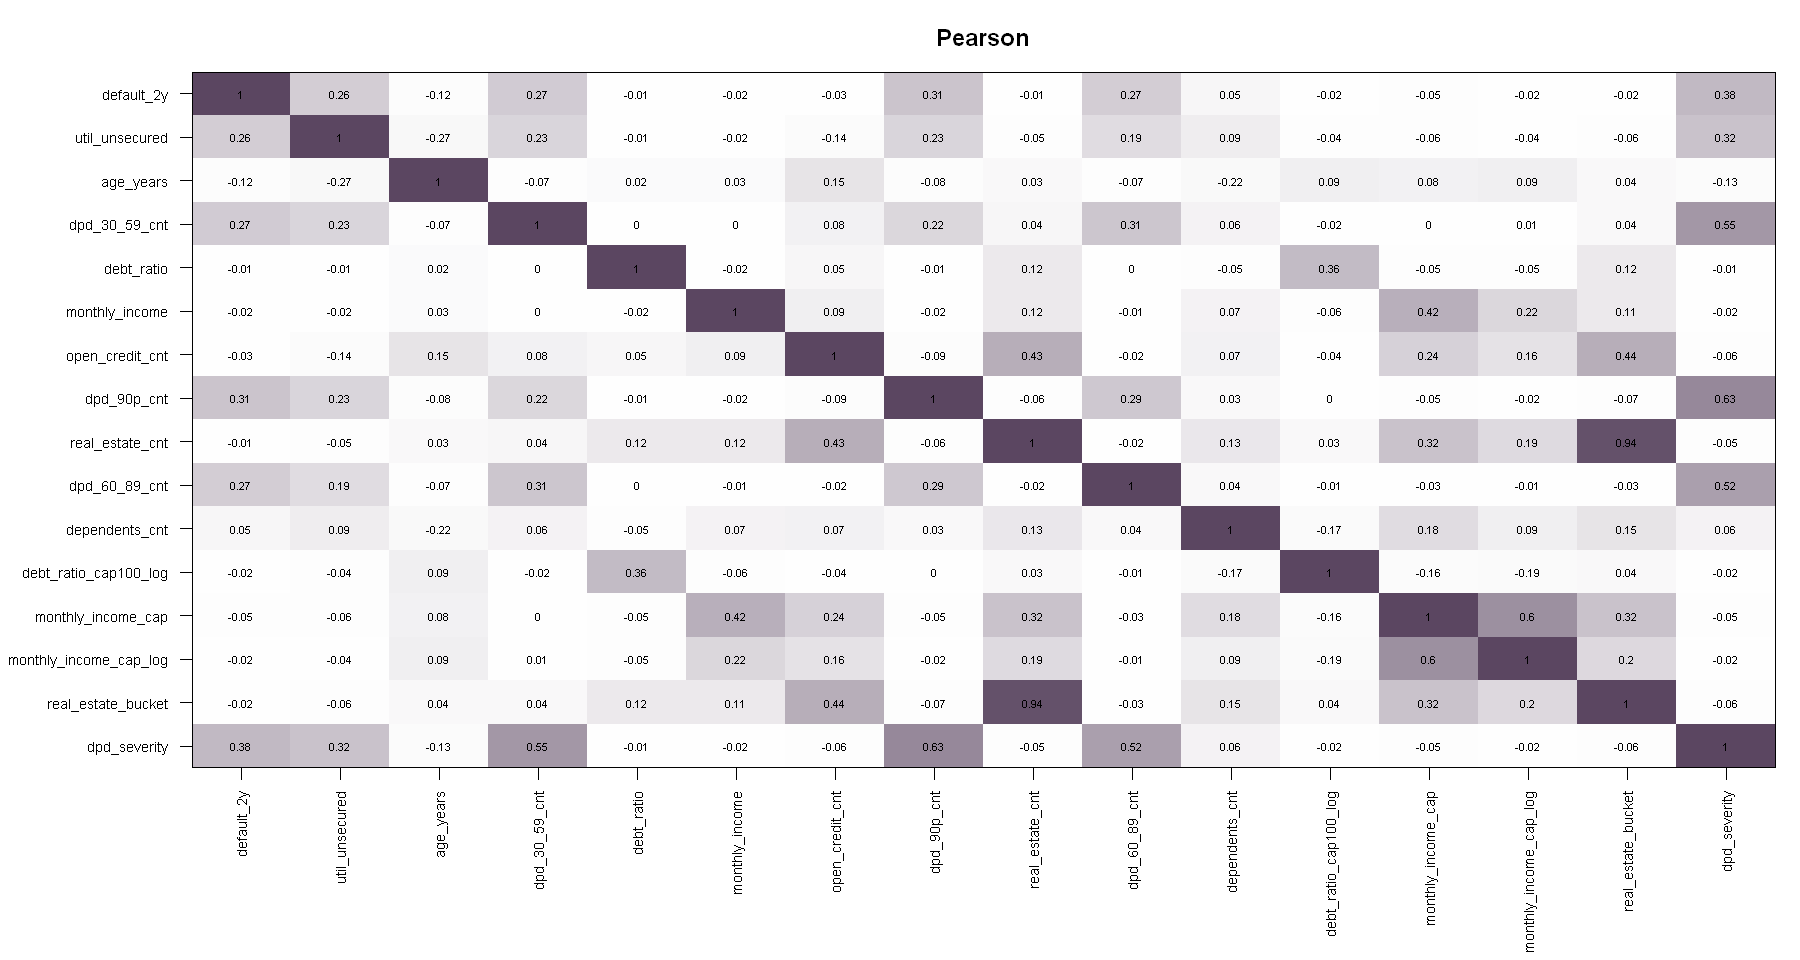

In [683]:
options(repr.plot.width = 15, repr.plot.height = 8)
cor_p <- cor(df[, num_cols], use="pairwise.complete.obs", method="pearson")
plot_corr_heatmap(cor_p, main="Pearson", show_values=TRUE)

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Spearman
  </div>
</div>

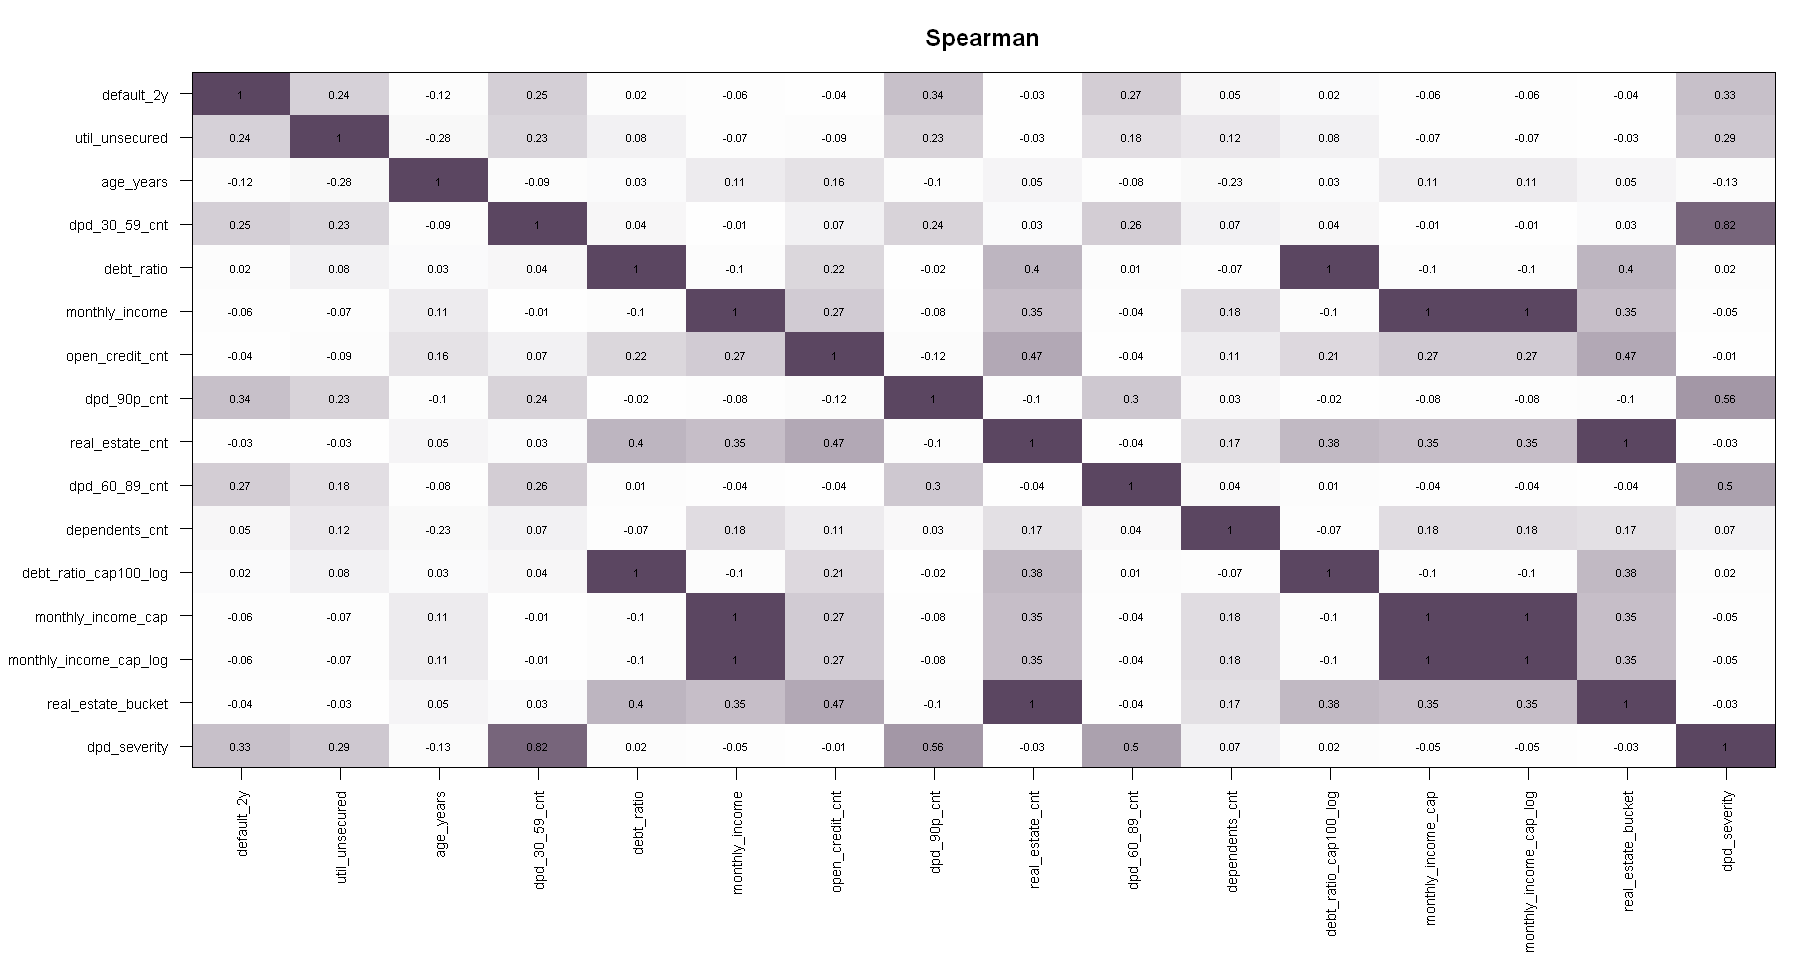

In [684]:
options(repr.plot.width = 15, repr.plot.height = 8)
cor_s <- cor(df[, num_cols], use="pairwise.complete.obs", method="spearman")
plot_corr_heatmap(cor_s, main="Spearman", show_values=TRUE)

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    Pearson & Spearman Results - Correlation
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    Strong signals:

    - dpd_severity: ~0.38 (Pearson) / ~0.33 (Spearman) → is the strongest univariate signal.
    - dpd_90p_cnt: ~0.31 / ~0.34 → strong (becomes redundant with dpd_severity).
    - dpd_60_89_cnt and dpd_30_59_cnt: ~0.27 / ~0.25–0.27 → good signals (becomes redundant with dpd_severity).
    - util_unsecured: ~0.26 / ~0.24 → quite relevant.

    Moderate signals:
    - age_years: ~-0.12 (older → lower risk) → maintain, it is stable.

    Weak signals: (correlation close to 0)
    - debt_ratio and cap/log versions (~0.02 or -0.02)
    - monthly_income* (between ~-0.02 and -0.07)
    - open_credit_cnt (~-0.03 to -0.04)
    - real_estate_* (~-0.01 to -0.04)
    - dependents_cnt (~0.05)

    Redundancy / Collinearity:
    - debt_ratio_cap100 ↔ debt_ratio_cap100_log
    - monthly_income ↔ monthly_income_cap ↔ monthly_income_cap_log
    - real_estate_cnt ↔ real_estate_bucket
    - ​​dpd_severity correlates strongly with dpd_*_cnt
    
  </div>
</div>

In [685]:
names(df)

[1] "id"                     "default_2y"             "util_unsecured"        
 [4] "age_years"              "dpd_30_59_cnt"          "debt_ratio"            
 [7] "monthly_income"         "open_credit_cnt"        "dpd_90p_cnt"           
[10] "real_estate_cnt"        "dpd_60_89_cnt"          "dependents_cnt"        
[13] "income_missing"         "dependents_missing"     "util_gt1"              
[16] "dr_bucket"              "debt_ratio_cap100_log"  "dpd_any_gt90"          
[19] "monthly_income_cap"     "monthly_income_cap_log" "real_estate_bucket"    
[22] "real_estate_bucket_grp" "dpd_severity"

In [686]:
# Drop Columns
df$dpd_30_59_cnt <- NULL
df$dpd_60_89_cnt <- NULL
df$dpd_90p_cnt <- NULL
df$monthly_income <- NULL
df$monthly_income_cap <- NULL
df$debt_ratio_cap100 <- NULL
df$debt_ratio <- NULL
df$debt_ratio_cap100 <- NULL
df$real_estate_cnt <- NULL
df$real_estate_bucket <- NULL
df$dpd_any_gt90 <- NULL
df$debt_ratio_cap100_log <- NULL

names(df)

[1] "id"                     "default_2y"             "util_unsecured"        
 [4] "age_years"              "open_credit_cnt"        "dependents_cnt"        
 [7] "income_missing"         "dependents_missing"     "util_gt1"              
[10] "dr_bucket"              "monthly_income_cap_log" "real_estate_bucket_grp"
[13] "dpd_severity"

<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    AUC
  </div>
</div>

In [687]:
auc_mw <- function(y, score) {
  ok <- !is.na(y) & !is.na(score)
  y <- y[ok]; score <- score[ok]
  r <- rank(score, ties.method="average")
  n1 <- sum(y==1); n0 <- sum(y==0)
  if (n1==0 || n0==0) return(NA_real_)
  (sum(r[y==1]) - n1*(n1+1)/2) / (n1*n0)
}

In [688]:
# For weak connections, the AUC will be analyzed.

auc_mw(df$default_2y, df$dr_bucket)

auc_mw(df$default_2y, df$monthly_income_cap_log)

auc_mw(df$default_2y, df$open_credit_cnt)

auc_mw(df$default_2y, df$real_estate_bucket_grp)

auc_mw(df$default_2y, df$dependents_cnt)

[1] 0.4867505

[1] 0.4286692

[1] 0.4544514

[1] 0.4595854

[1] 0.5471977

<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    AUC
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    dr_bucket → 0.486
    0.50 -> random.
    Weak, variable can be discarded as KDE, decis and violin plot did not provide concrete analysis.

    open_credit_cnt → 0.454
    Weak signal.
    U-shape seen in the bivariate which may indicate something at the extremes -> keep.

    real_estate_bucket_grp → 0.459
    Random.
    Weak, variable can be discarded as KDE, decis and violin plot did not provide concrete analysis.

    monthly_income_cap_log → 0.423
    Moderate -> keep.

    dependents_cnt → 0.547
    Moderate -> keep.
  </div>
</div>

In [689]:
df$dr_bucket <- NULL
df$real_estate_bucket_grp <- NULL

names(df)

[1] "id"                     "default_2y"             "util_unsecured"        
 [4] "age_years"              "open_credit_cnt"        "dependents_cnt"        
 [7] "income_missing"         "dependents_missing"     "util_gt1"              
[10] "monthly_income_cap_log" "dpd_severity"

In [690]:
head(df, 10)

id,default_2y,util_unsecured,age_years,open_credit_cnt,dependents_cnt,income_missing,dependents_missing,util_gt1,monthly_income_cap_log,dpd_severity
1,1,0.5687888,45,13,2,FALSE,FALSE,FALSE,9.118335,1
2,0,0.6714899,40,4,1,FALSE,FALSE,FALSE,7.863651,0
3,0,0.5057207,38,2,0,FALSE,FALSE,FALSE,8.020599,3
4,0,0.2101068,30,5,0,FALSE,FALSE,FALSE,8.101981,0
5,0,0.6456569,49,7,0,FALSE,FALSE,FALSE,10.349807,1
6,0,0.1932439,74,3,1,FALSE,FALSE,FALSE,8.160804,0
7,0,0.2667259,57,8,0,TRUE,FALSE,FALSE,8.594339,0
8,0,0.5621632,39,8,0,FALSE,FALSE,FALSE,8.160804,0
9,0,0.1106023,27,2,0,TRUE,TRUE,FALSE,8.594339,0
10,0,0.1732548,57,9,2,FALSE,FALSE,FALSE,10.072597,0


<!-- Subsection header (ultra-compact) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: #5B4661;
  border: 1px solid rgba(255,255,255,0.18);
  color: #ffffff;
  padding: 8px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .12em;
    text-transform: uppercase;
    opacity: .92;
    font-weight: 800;
  ">
    Cramér’s V + summary table
  </div>
</div>

In [691]:
# --- Cramér's V (base R) ---
cramers_v <- function(x, y, correct_bias = TRUE) {
  ok <- !is.na(x) & !is.na(y)
  x <- as.factor(x[ok]); y <- as.factor(y[ok])

  tab <- table(x, y)
  if (nrow(tab) < 2 || ncol(tab) < 2) return(NA_real_)

  suppressWarnings({
    chi2 <- chisq.test(tab, correct = FALSE)$statistic
  })

  n <- sum(tab)
  r <- nrow(tab); k <- ncol(tab)
  phi2 <- as.numeric(chi2) / n

  if (!correct_bias) {
    return(sqrt(phi2 / min(r - 1, k - 1)))
  }


  phi2_corr <- max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
  r_corr <- r - ((r - 1)^2) / (n - 1)
  k_corr <- k - ((k - 1)^2) / (n - 1)

  sqrt(phi2_corr / min(r_corr - 1, k_corr - 1))
}

cramers_v_target <- function(df, target = "default_2y", cat_cols = NULL) {
  if (is.null(cat_cols)) {
    cat_cols <- names(df)[!sapply(df, is.numeric)]
  }
  cat_cols <- setdiff(cat_cols, target)

  res <- data.frame(
    var = cat_cols,
    cramer_v = NA_real_,
    chi_pvalue = NA_real_,
    n_used = NA_integer_,
    stringsAsFactors = FALSE
  )

  y_all <- df[[target]]

  for (i in seq_along(cat_cols)) {
    x_all <- df[[cat_cols[i]]]
    ok <- !is.na(x_all) & !is.na(y_all)
    x <- as.factor(x_all[ok])
    y <- as.factor(y_all[ok])

    tab <- table(x, y)
    res$n_used[i] <- sum(tab)

    if (nrow(tab) < 2 || ncol(tab) < 2) next

    suppressWarnings({
      tst <- chisq.test(tab, correct = FALSE)
    })
    res$chi_pvalue[i] <- tst$p.value
    res$cramer_v[i] <- cramers_v(x, y, correct_bias = TRUE)
  }

  res[order(res$cramer_v, decreasing = TRUE), ]
}

In [692]:
cat_cols <- c("income_missing","dependents_missing","util_gt1","dpd_severity")
cramers_v_target(df, target="default_2y", cat_cols=cat_cols)

,var,cramer_v,chi_pvalue,n_used
4,dpd_severity,0.38122915,0.000000e+00,149390
3,util_gt1,0.18421282,0.000000e+00,149390
1,income_missing,0.02034034,2.280274e-15,149390
2,dependents_missing,0.01304226,2.759438e-07,149390


<!-- Note / comment box (minimal) -->
<div style="
  font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial;
  background: rgba(170,170,170,0.10);
  border: 1px solid rgba(170,170,170,0.22);
  color: rgba(255,255,255,0.82);
  padding: 10px 12px;
  border-radius: 12px;
  margin: 10px 0 12px 0;
">
  <div style="
    font-size: 12px;
    letter-spacing: .10em;
    text-transform: uppercase;
    opacity: .75;
    font-weight: 800;
    margin-bottom: 6px;
  ">
    AUC
  </div>
  <div style="font-size: 13px; line-height: 1.55;">
    <!-- Write your comment here -->
    
    How to interpret Cramer's V:
        0.00 – 0.05 → practically nothing
        0.05 – 0.15 → weak
        0.15 – 0.30 → moderate
        0.30 → strong
    dependents_missing -> Irrelevant for the target.
  </div>
</div>

In [693]:
df$dependents_missing <- NULL

names(df)

[1] "id"                     "default_2y"             "util_unsecured"        
 [4] "age_years"              "open_credit_cnt"        "dependents_cnt"        
 [7] "income_missing"         "util_gt1"               "monthly_income_cap_log"
[10] "dpd_severity"

In [694]:
# Export to csv -> EDA 3
write.csv(df, file = "cs_train_features.csv", row.names = FALSE)